<a href="https://colab.research.google.com/github/qorwlghks/26-BDA/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 69.6 MB/s eta 0:00:00


In [8]:
!pip install pydataset
from pydataset import data
iris = data('iris')
iris.info()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 45.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=4246b561ddc61dd21e9374fb44d2dc3207fe56ab7c5f4a65c712f7b9038dedd0
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset
initiated datasets repo at: /root/.pydataset/
<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [9]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
iris.Species.value_counts

<bound method IndexOpsMixin.value_counts of 1          setosa
2          setosa
3          setosa
4          setosa
5          setosa
6          setosa
7          setosa
8          setosa
9          setosa
10         setosa
11         setosa
12         setosa
13         setosa
14         setosa
15         setosa
16         setosa
17         setosa
18         setosa
19         setosa
20         setosa
21         setosa
22         setosa
23         setosa
24         setosa
25         setosa
26         setosa
27         setosa
28         setosa
29         setosa
30         setosa
31         setosa
32         setosa
33         setosa
34         setosa
35         setosa
36         setosa
37         setosa
38         setosa
39         setosa
40         setosa
41         setosa
42         setosa
43         setosa
44         setosa
45         setosa
46         setosa
47         setosa
48         setosa
49         setosa
50         setosa
51     versicolor
52     versicolor
53     versicolor
54     versicolor
55     versicolor
56     versicolor
57     versicolor
58     versicolor
59     versicolor
60     versicolor
61     versicolor
62     versicolor
63     versicolor
64     versicolor
65     versicolor
66     versicolor
67     versicolor
68     versicolor
69     versicolor
70     versicolor
71     versicolor
72     versicolor
73     versicolor
74     versicolor
75     versicolor
76     versicolor
77     versicolor
78     versicolor
79     versicolor
80     versicolor
81     versicolor
82     versicolor
83     versicolor
84     versicolor
85     versicolor
86     versicolor
87     versicolor
88     versicolor
89     versicolor
90     versicolor
91     versicolor
92     versicolor
93     versicolor
94     versicolor
95     versicolor
96     versicolor
97     versicolor
98     versicolor
99     versicolor
100    versicolor
101     virginica
102     virginica
103     virginica
104     virginica
105     virginica
106     virginica
107     virginica
108     virginica
109     virginica
110     virginica
111     virginica
112     virginica
113     virginica
114     virginica
115     virginica
116     virginica
117     virginica
118     virginica
119     virginica
120     virginica
121     virginica
122     virginica
123     virginica
124     virginica
125     virginica
126     virginica
127     virginica
128     virginica
129     virginica
130     virginica
131     virginica
132     virginica
133     virginica
134     virginica
135     virginica
136     virginica
137     virginica
138     virginica
139     virginica
140     virginica
141     virginica
142     virginica
143     virginica
144     virginica
145     virginica
146     virginica
147     virginica
148     virginica
149     virginica
150     virginica
Name: Species, dtype: object>

In [11]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [12]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [19]:
display_series_side_by_side(iris['Petal.Length'][:5], iris['Species'].value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [20]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

AttributeError: 'DataFrame' object has no attribute 'name'

In [22]:
import matplotlib.pyplot as plt

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


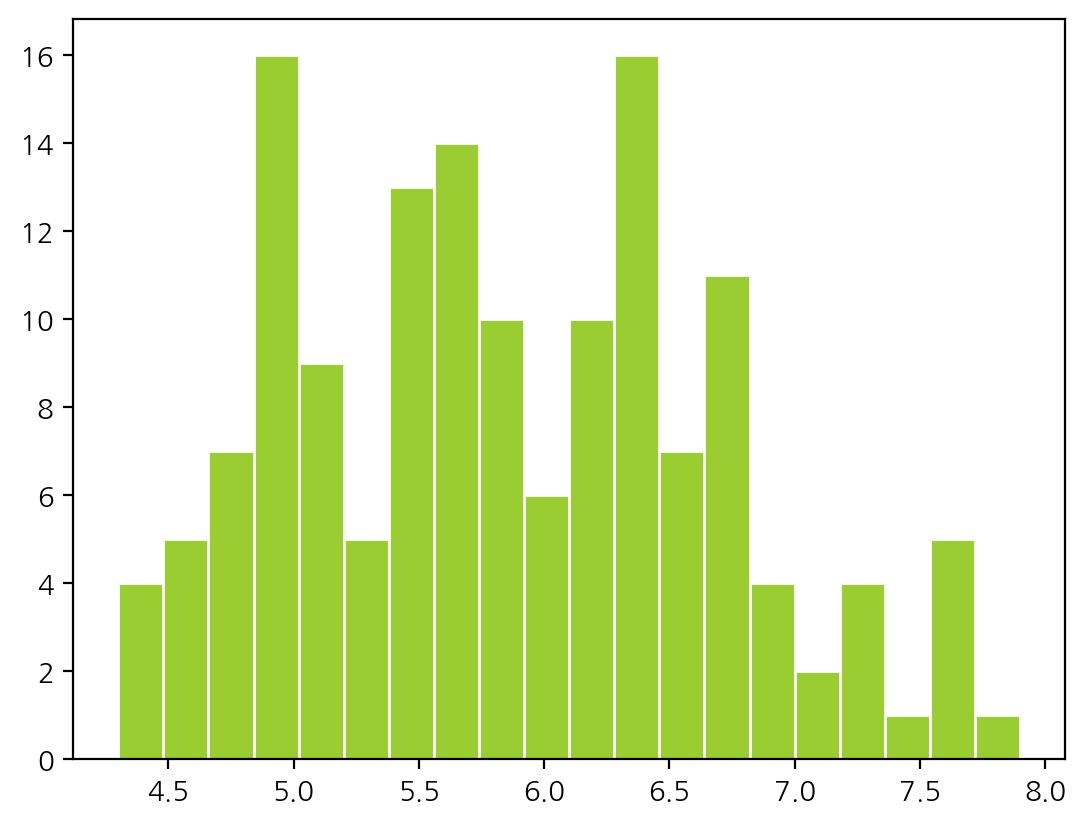

In [23]:
n,bins,patches = plt.hist(iris['Sepal.Length'], bins =20,
                          color ='yellowgreen', edgecolor='white')
print(n)
print(bins)
print(patches)

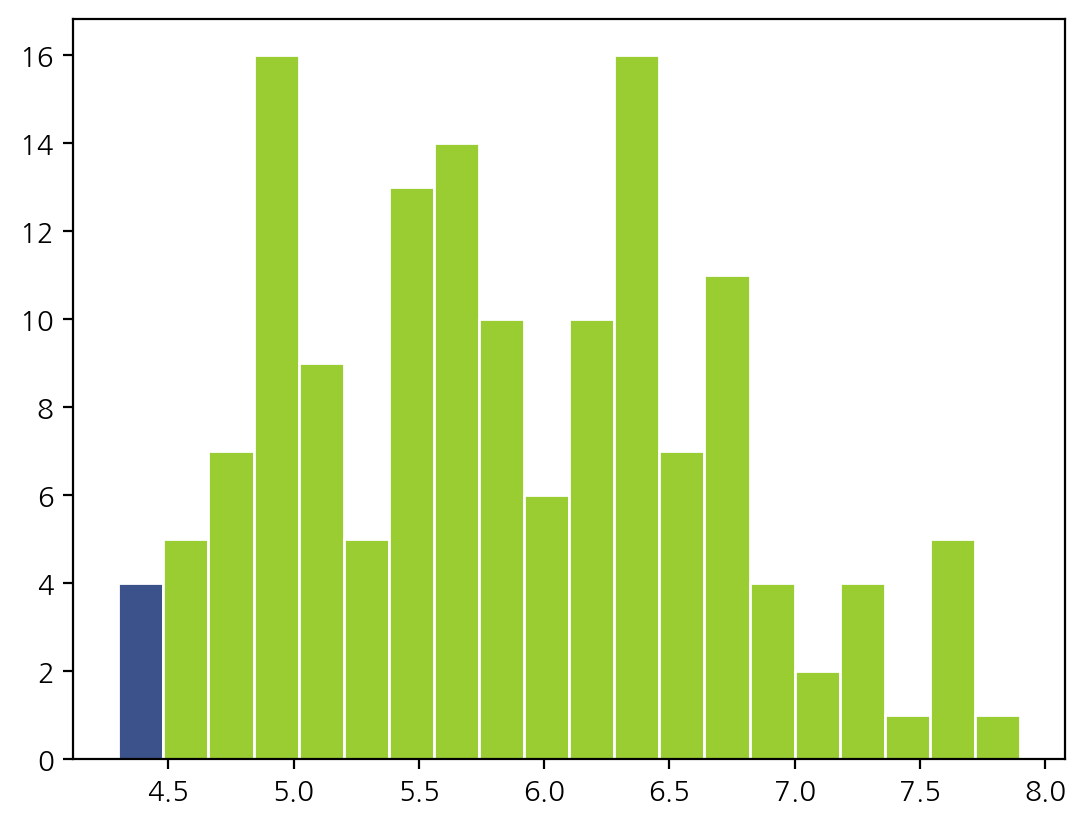

In [25]:
n,bins,patches = plt.hist(iris['Sepal.Length'],
                          bins =20,
                          color ='yellowgreen',
                          edgecolor='white')
for i in range(len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
  plt.show()

In [ ]:
plt.rcParams['figure']

<Axes: ylabel='Density'>

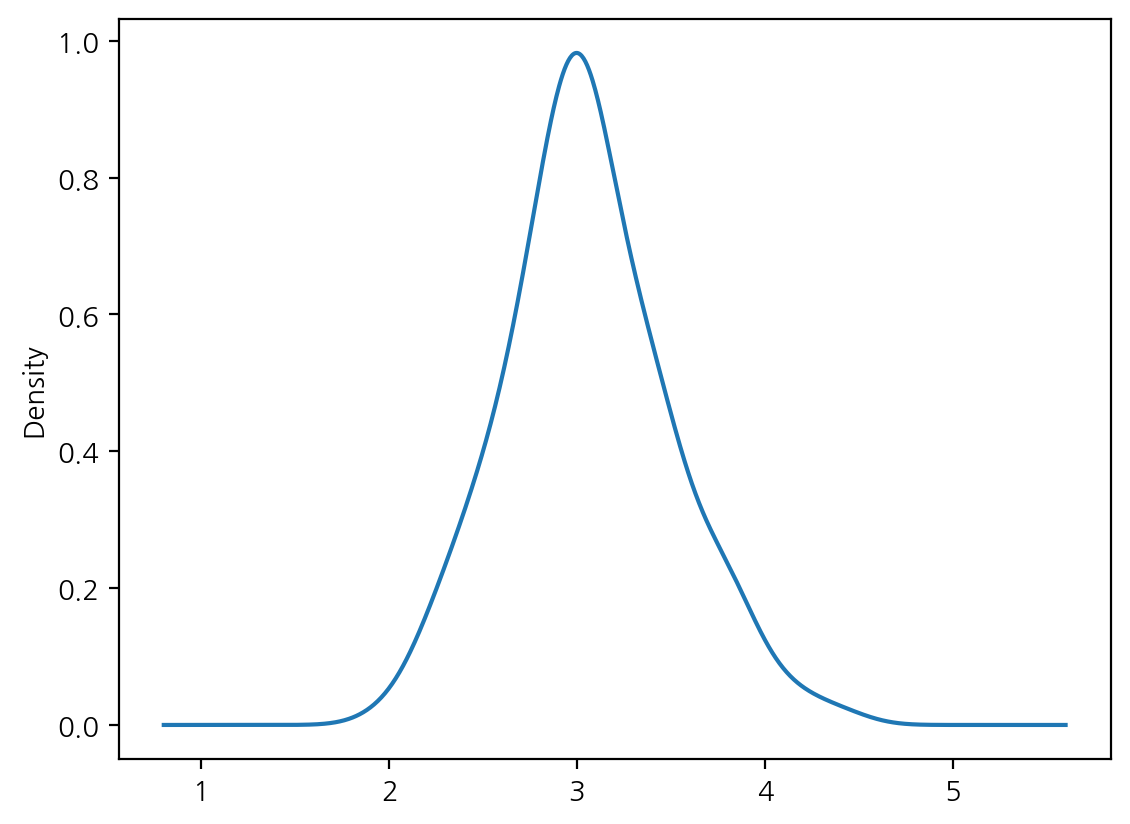

In [26]:
iris['Sepal.Width'].plot.density()

<Axes: ylabel='Density'>

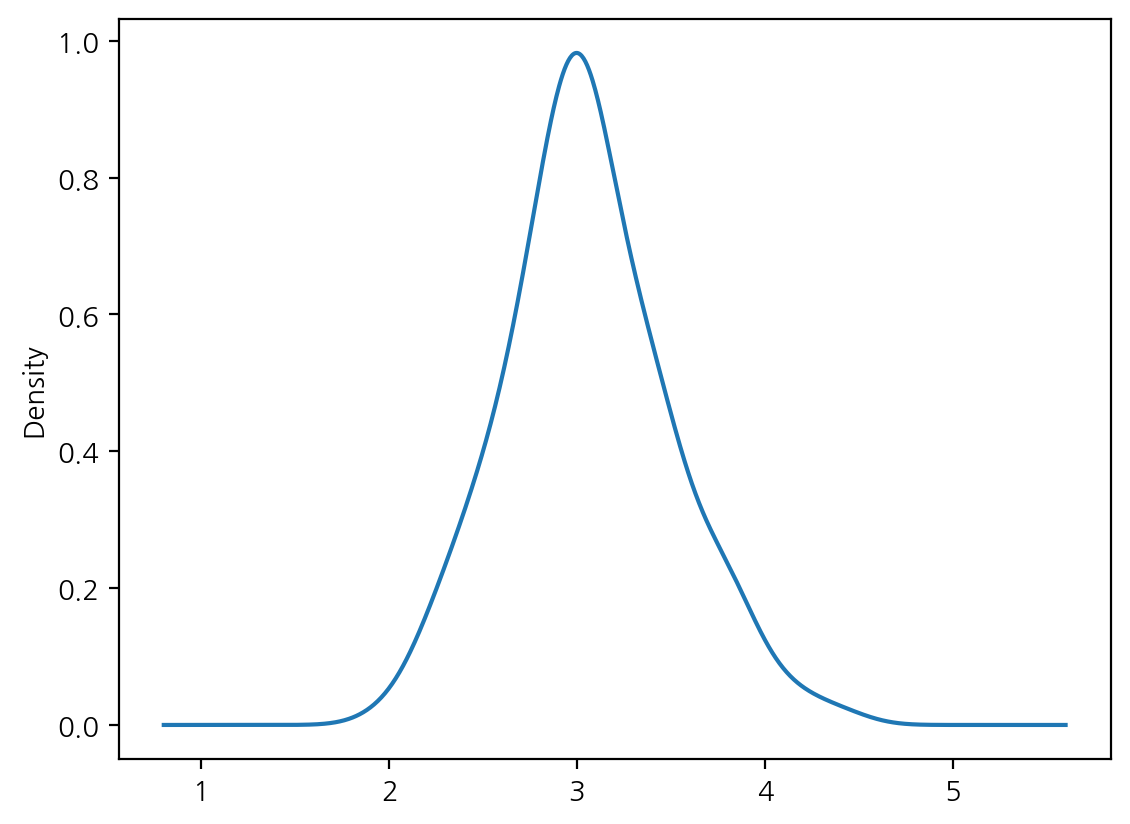

In [28]:
iris['Sepal.Width'].plot.kde()

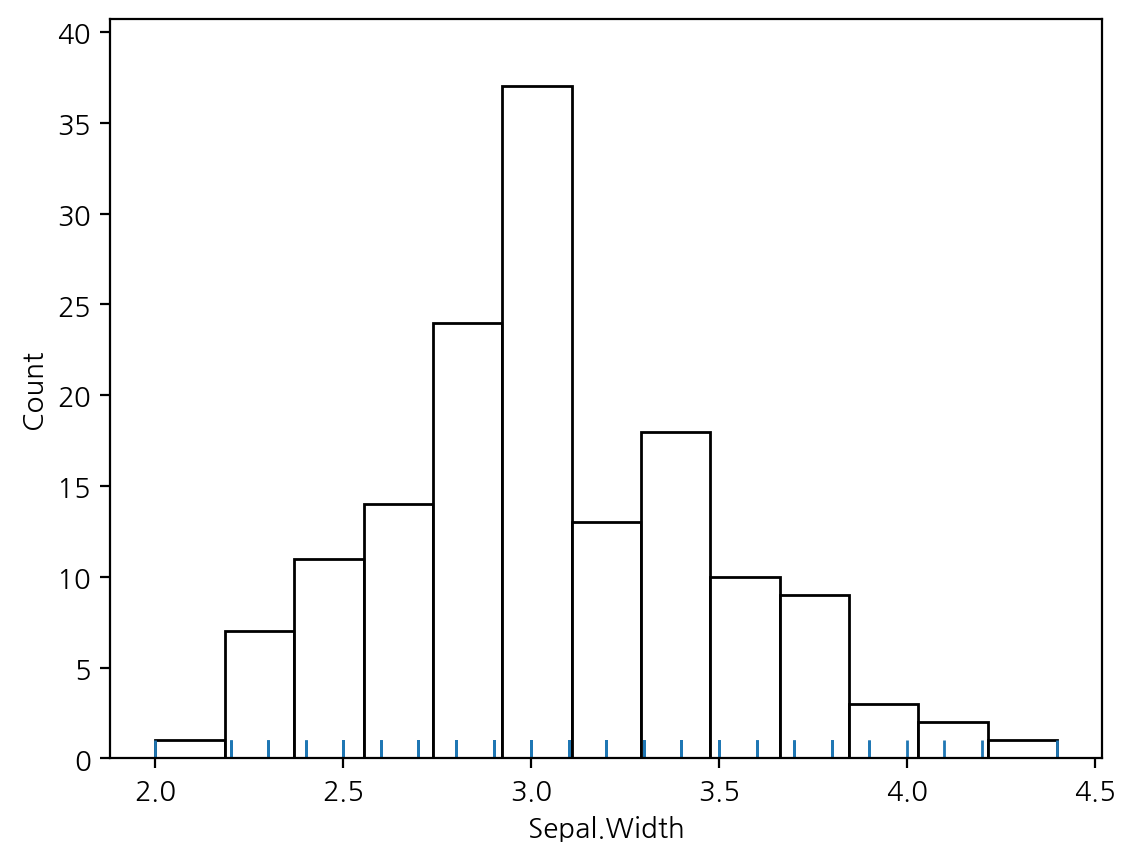

In [29]:
import seaborn as sns
sns.histplot(data=iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x = iris['Sepal.Width']);

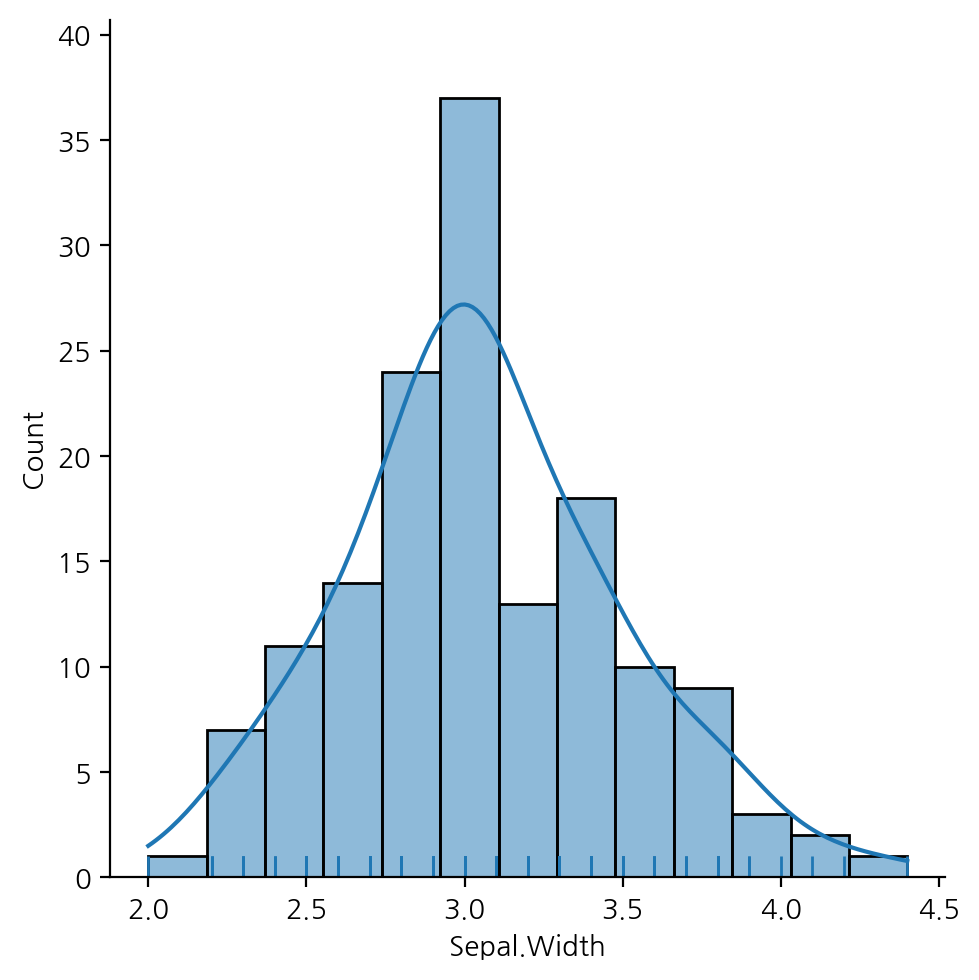

In [30]:
import seaborn as sns
sns.displot(data=iris, x = iris['Sepal.Width'], kde=True, rug=True);

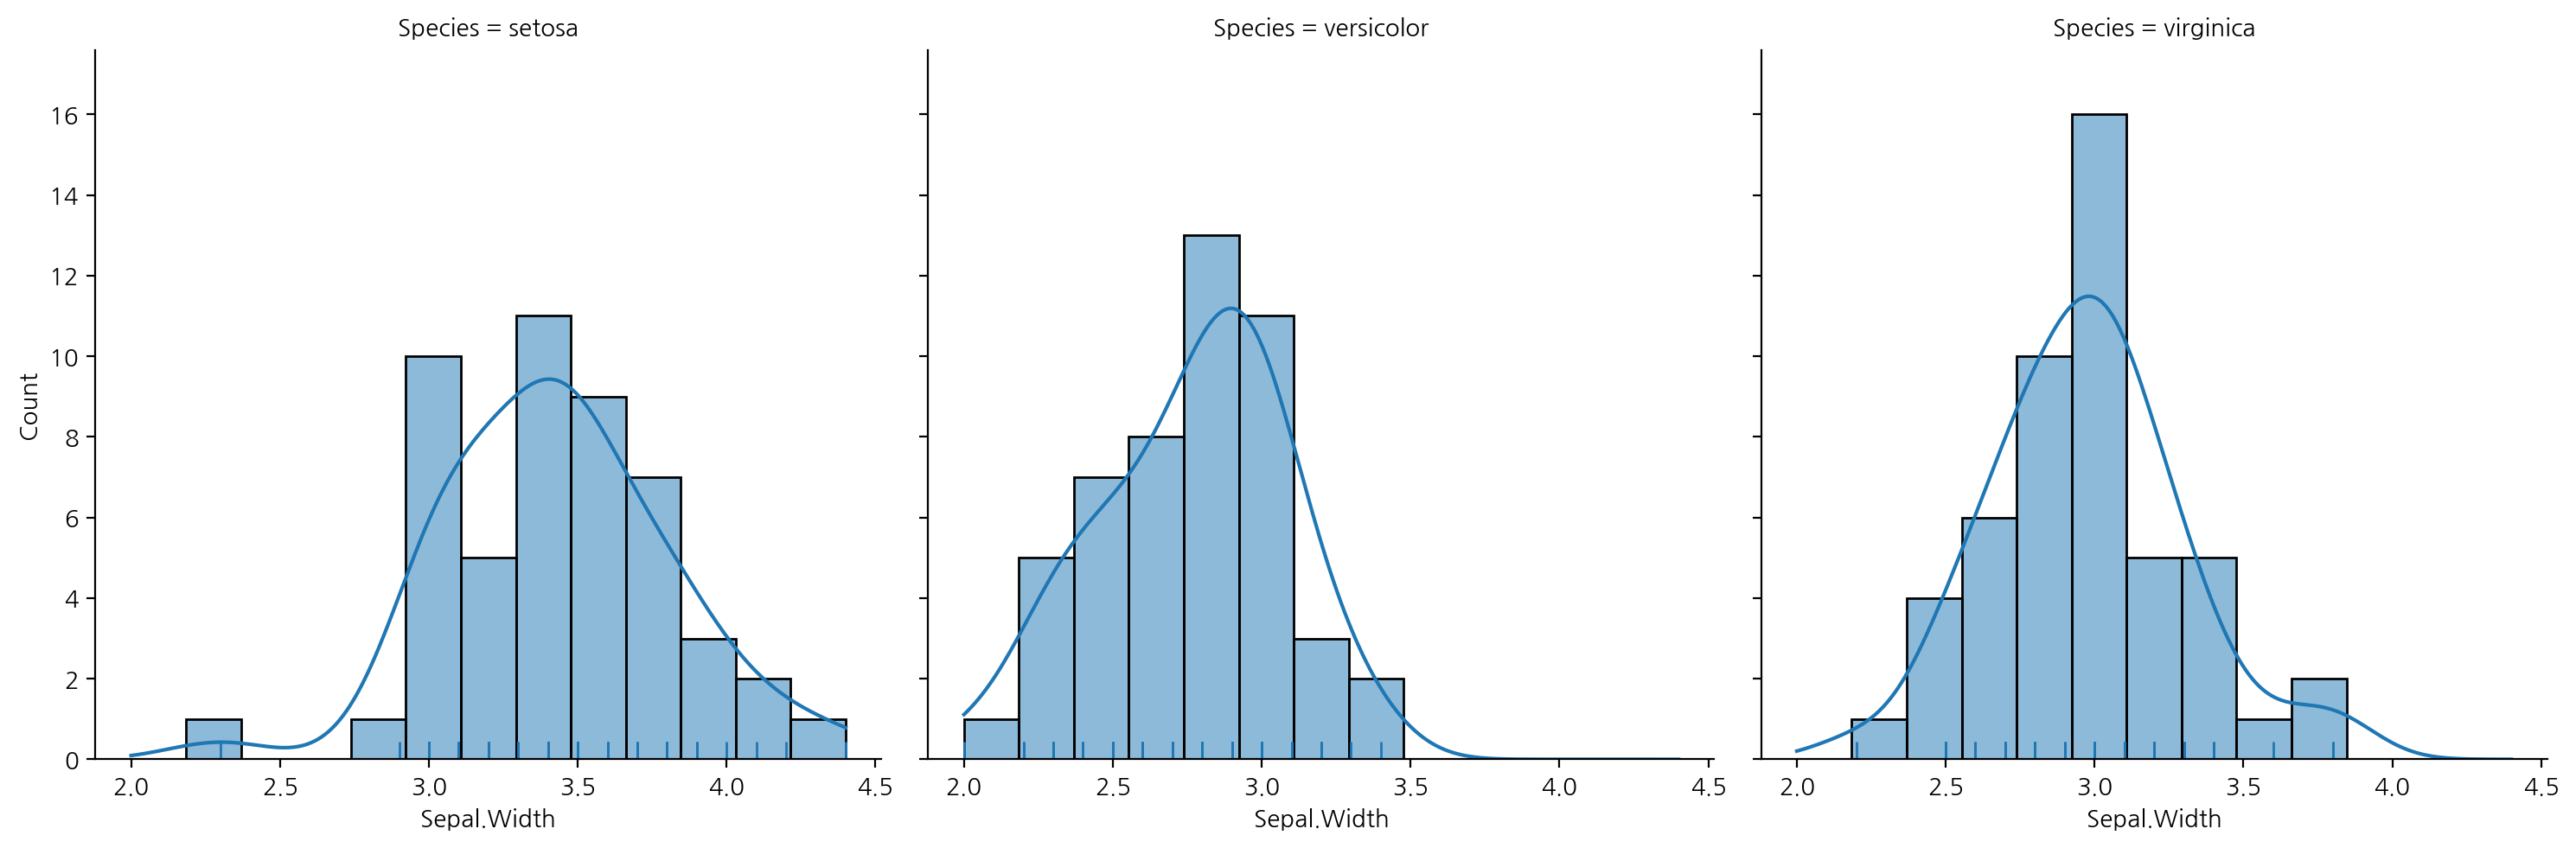

In [31]:
sns.displot(data =iris, x =iris['Sepal.Width'], col="Species",
            kde=True, rug=True);

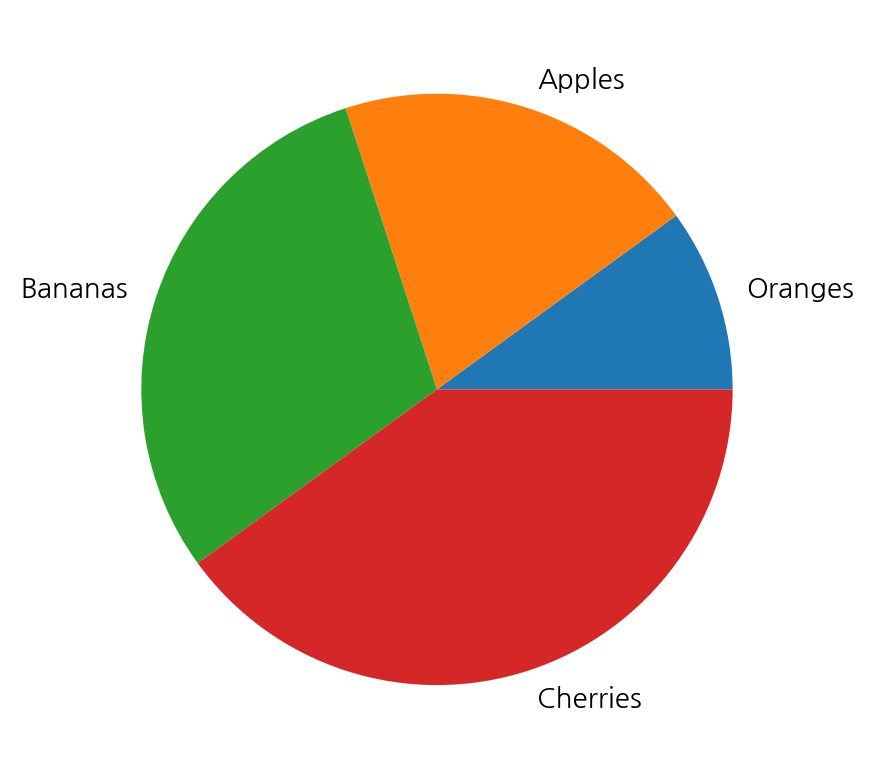

In [32]:
fruits = ["Oranges", "Apples", "Bananas", "Cherries"]
plt.pie([10,20,30,40], labels=fruits);

In [35]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


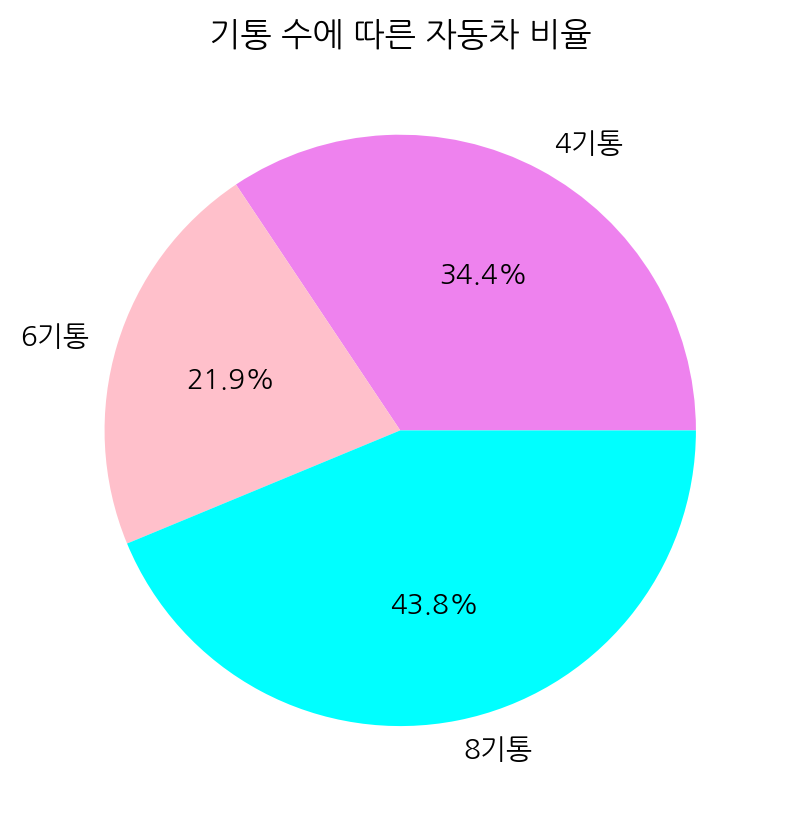

In [37]:
txt = mtc.cyl.value_counts().sort_index().index.astype(str) + '기통'
plt.pie(mtc.cyl.value_counts().sort_index(),
        colors = ["violet", "pink", "aqua"],
        autopct='%.1f%%', labels = txt)
plt.title("기통 수에 따른 자동차 비율");

In [38]:
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


In [39]:
mtc.cyl.value_counts().sort_index().index

Index([4, 6, 8], dtype='int64', name='cyl')

In [40]:
txt = [str(i) + '기통' for i in mtc.cyl.value_counts().sort_index().index]
txt

['4기통', '6기통', '8기통']

In [42]:
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


In [43]:
labels = [str(i) + '기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3기어', '4기어', '5기어']

In [44]:
colors = sns.color_palette('Accent', len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [45]:
import pandas as pd
pd.set_option('display.precision',3)
corr_iris = iris[iris.columns[:-1].to_list()].corr()
corr_iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.000,-0.118,0.872,0.818
Sepal.Width,-0.118,1.000,-0.428,-0.366
Petal.Length,0.872,-0.428,1.000,0.963
Petal.Width,0.818,-0.366,0.963,1.000


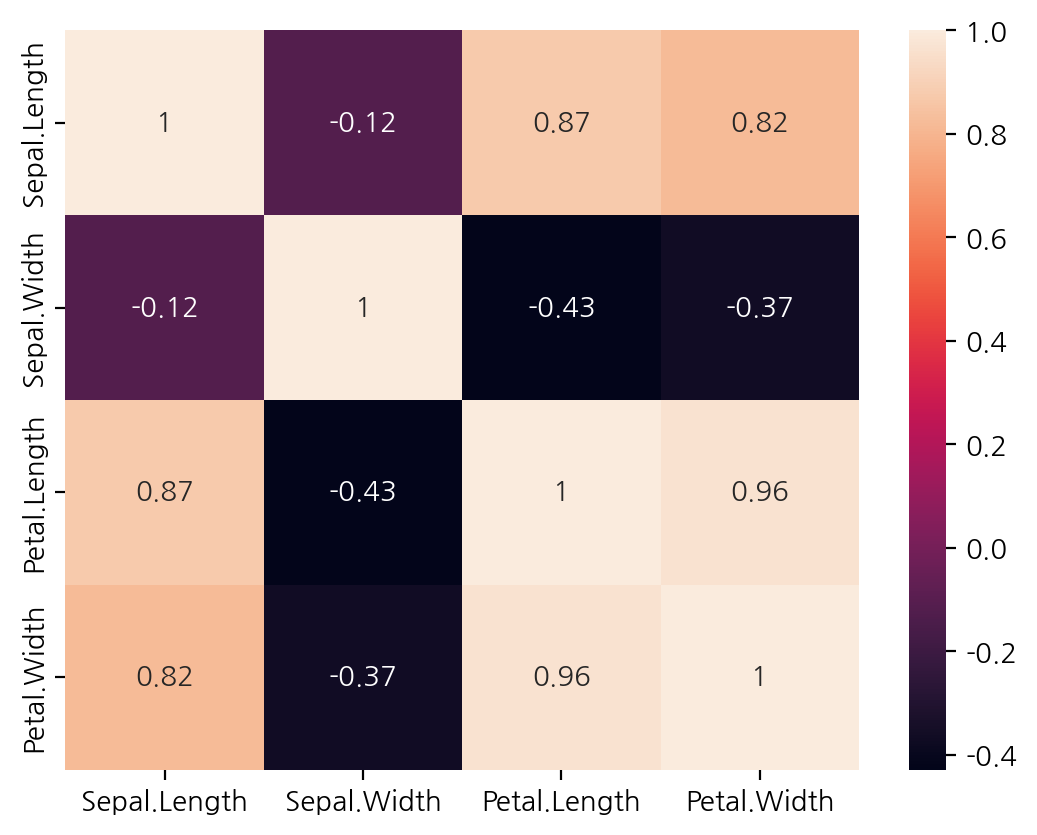

In [46]:
sns.heatmap(corr_iris, annot=True);

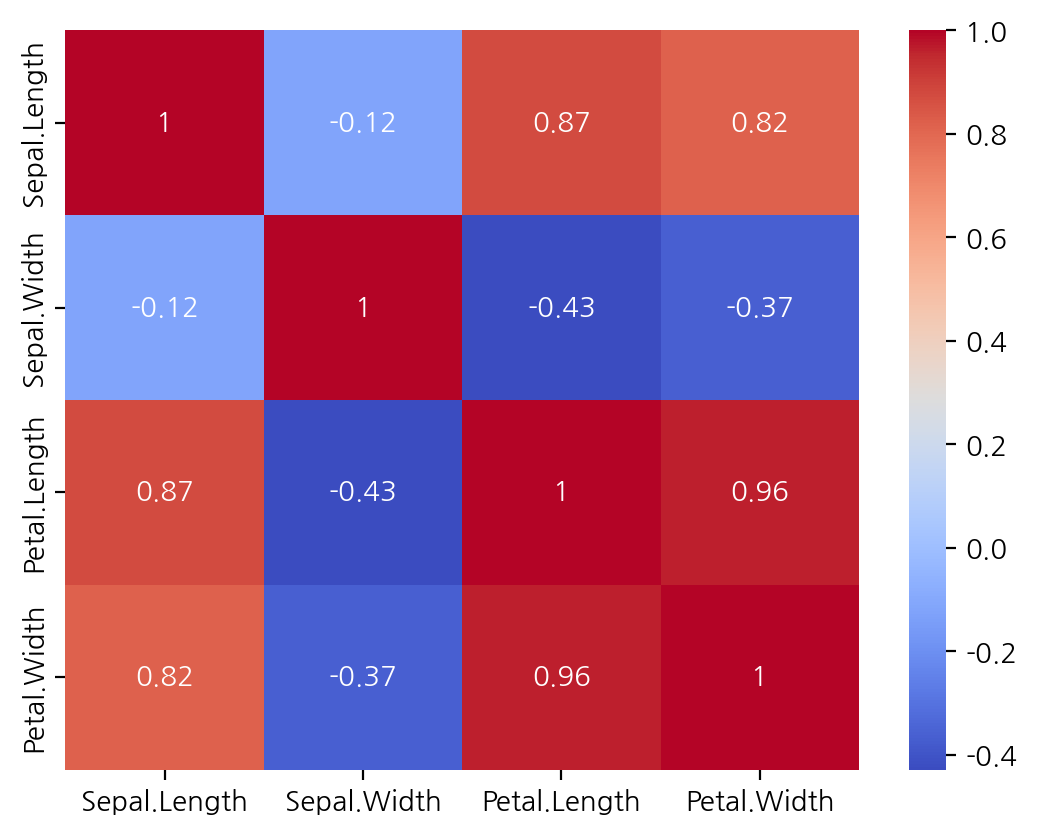

In [48]:
sns.heatmap(corr_iris, cmap='coolwarm', annot=True);

In [49]:
import numpy as np
mask = np.zeros_like(corr_iris)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [50]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [51]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [52]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

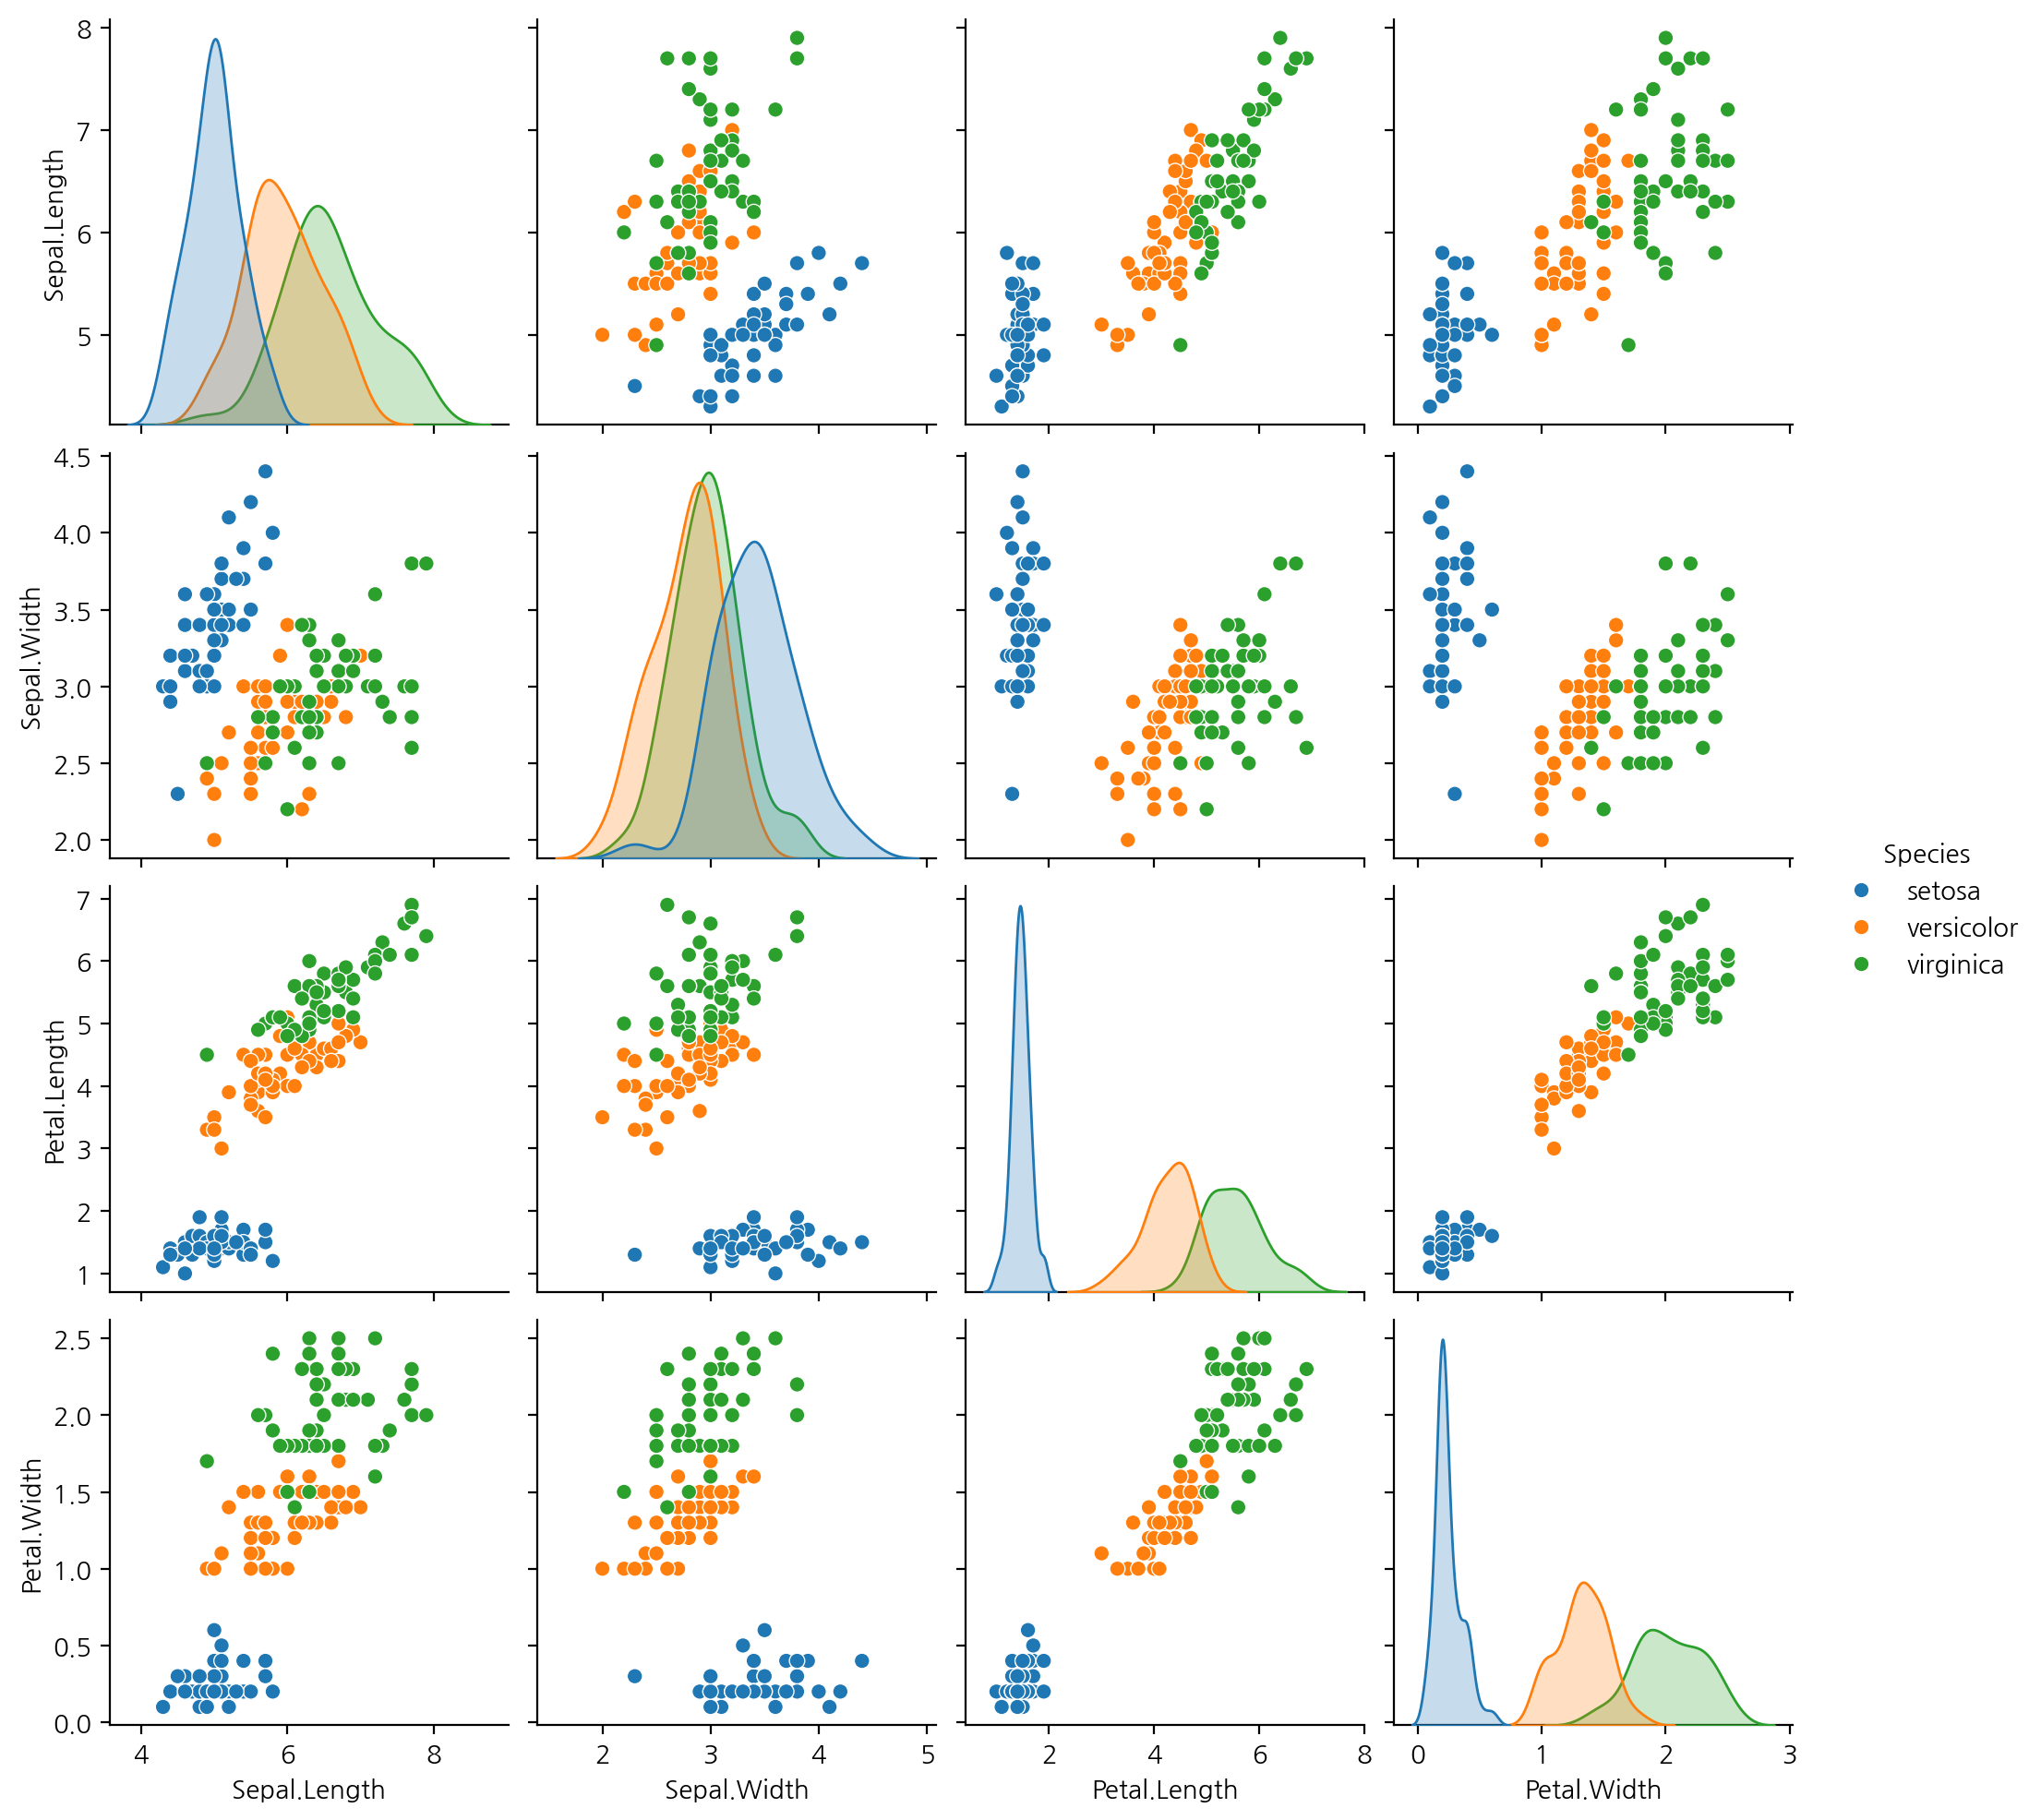

In [56]:
sns.pairplot(iris, hue='Species')

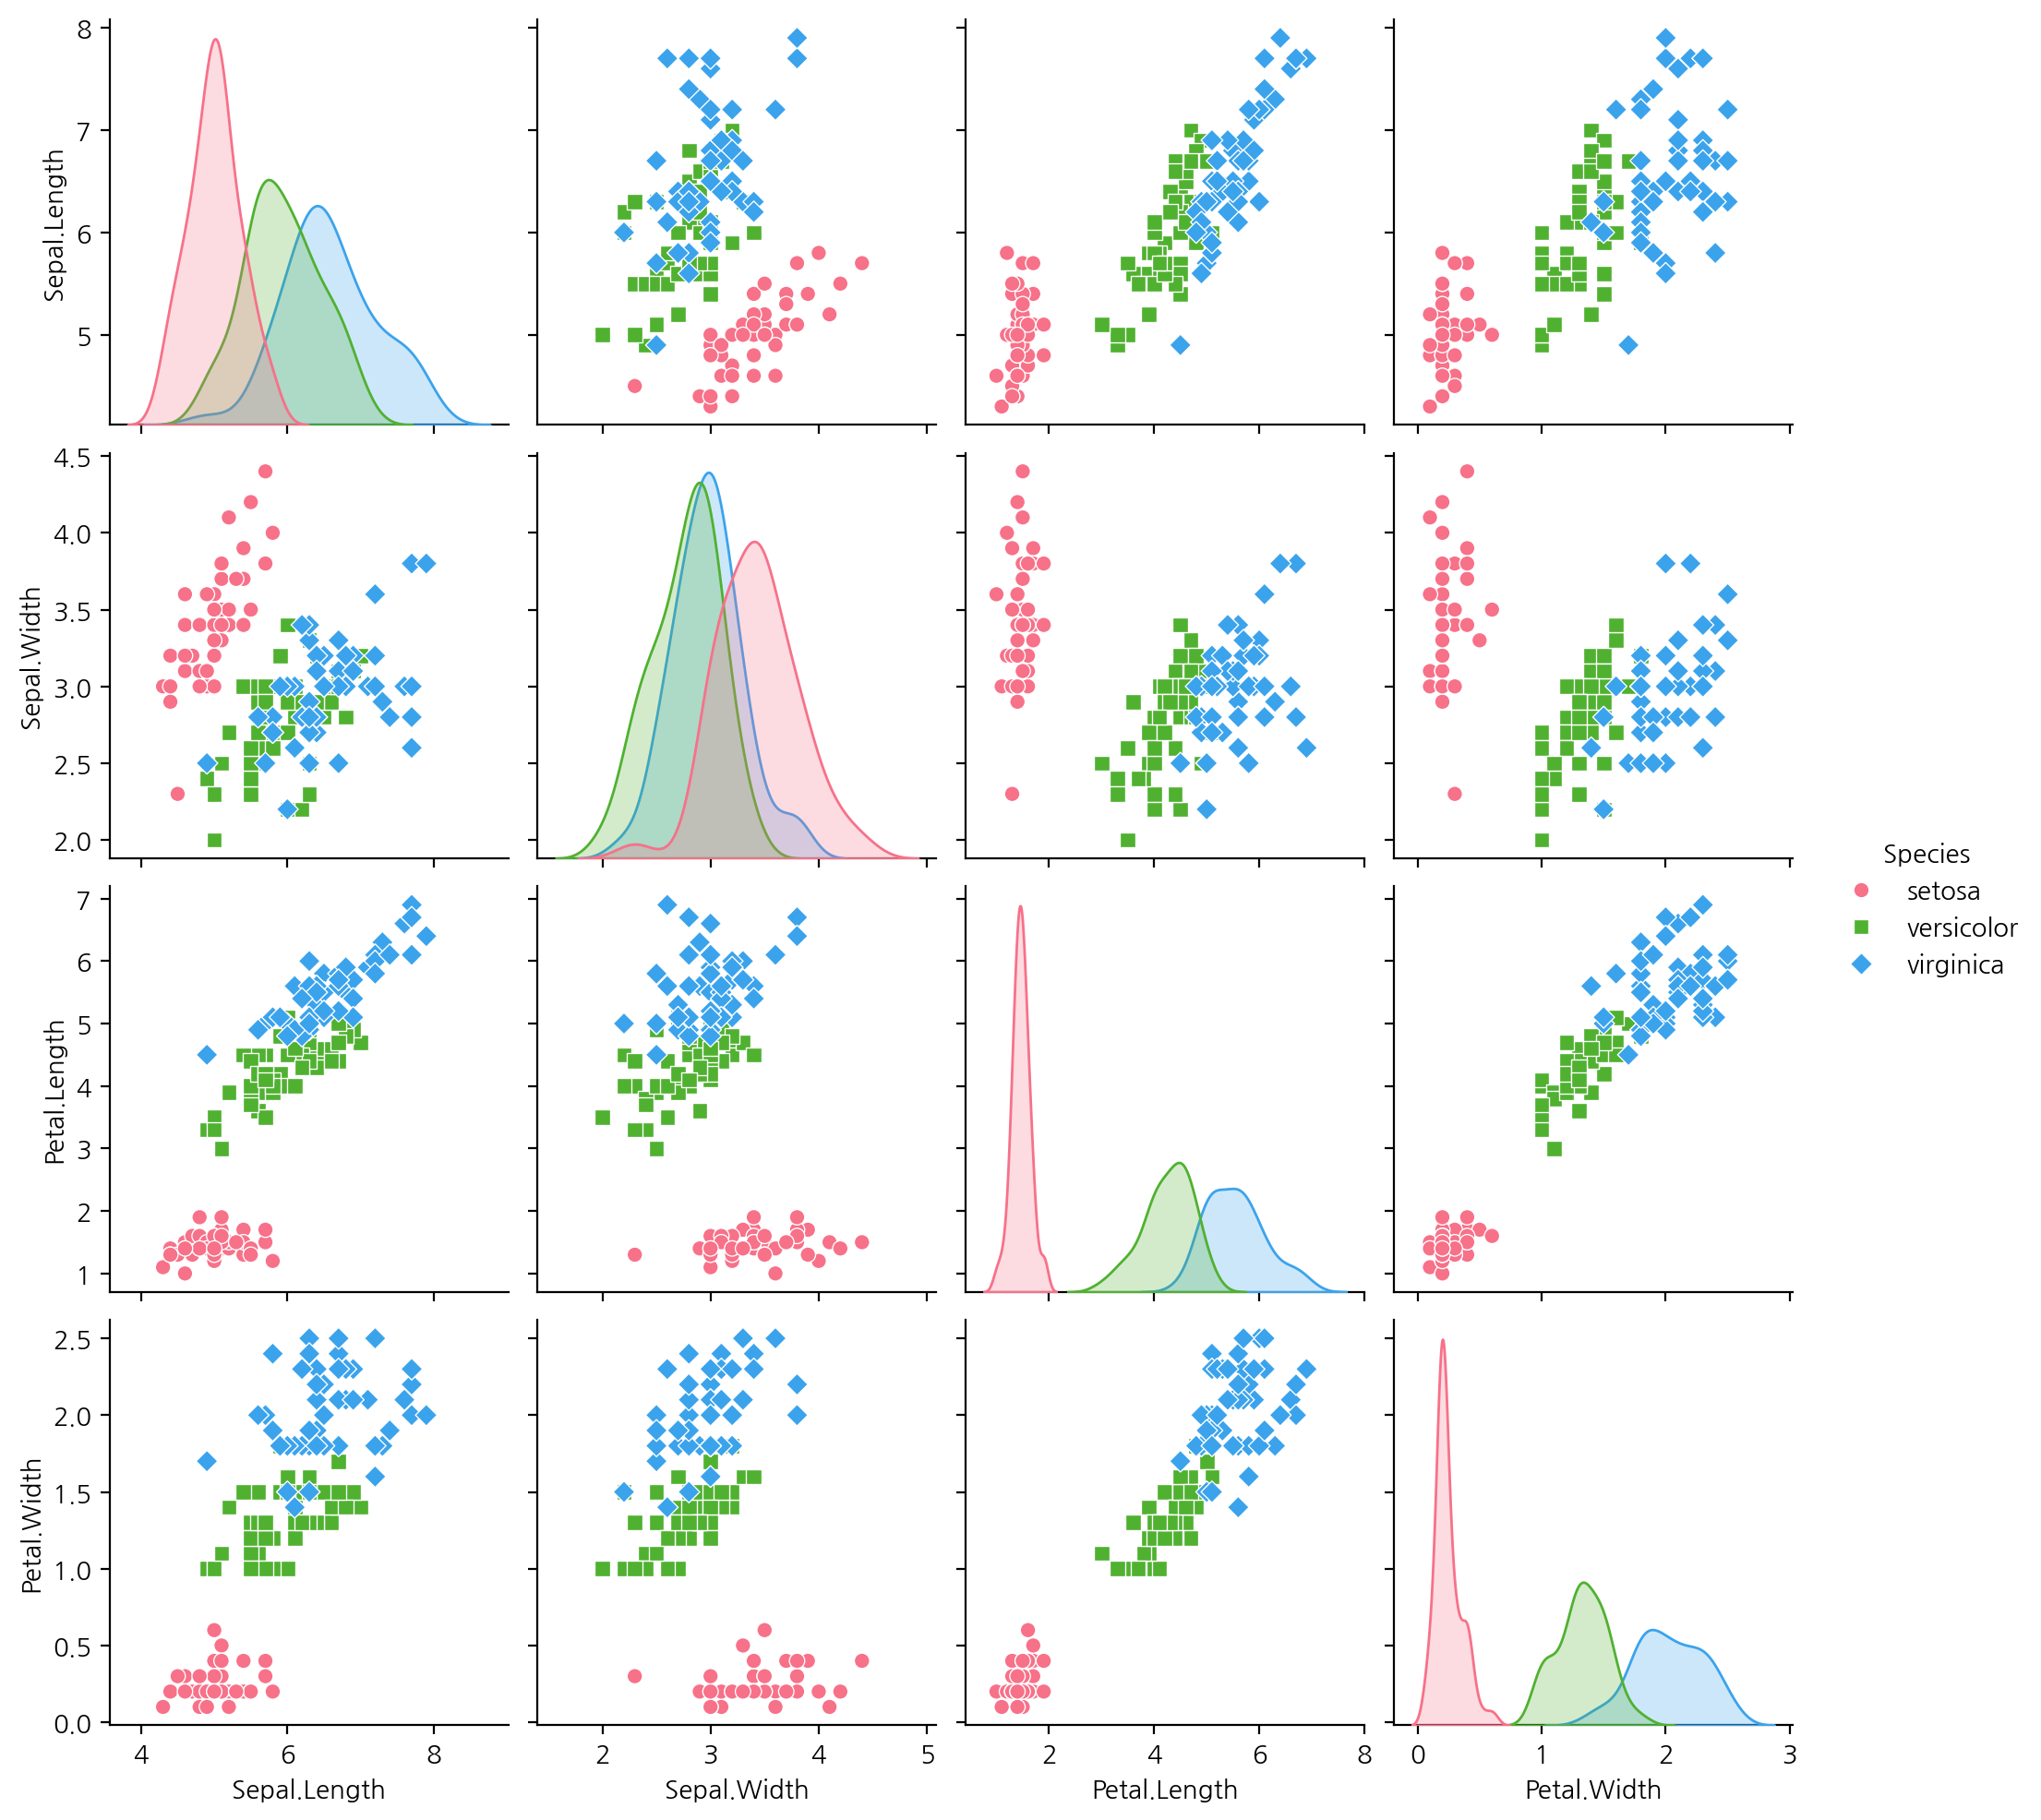

In [57]:
sns.pairplot(iris, hue="Species", palette="husl", markers=["o","s","D"]);

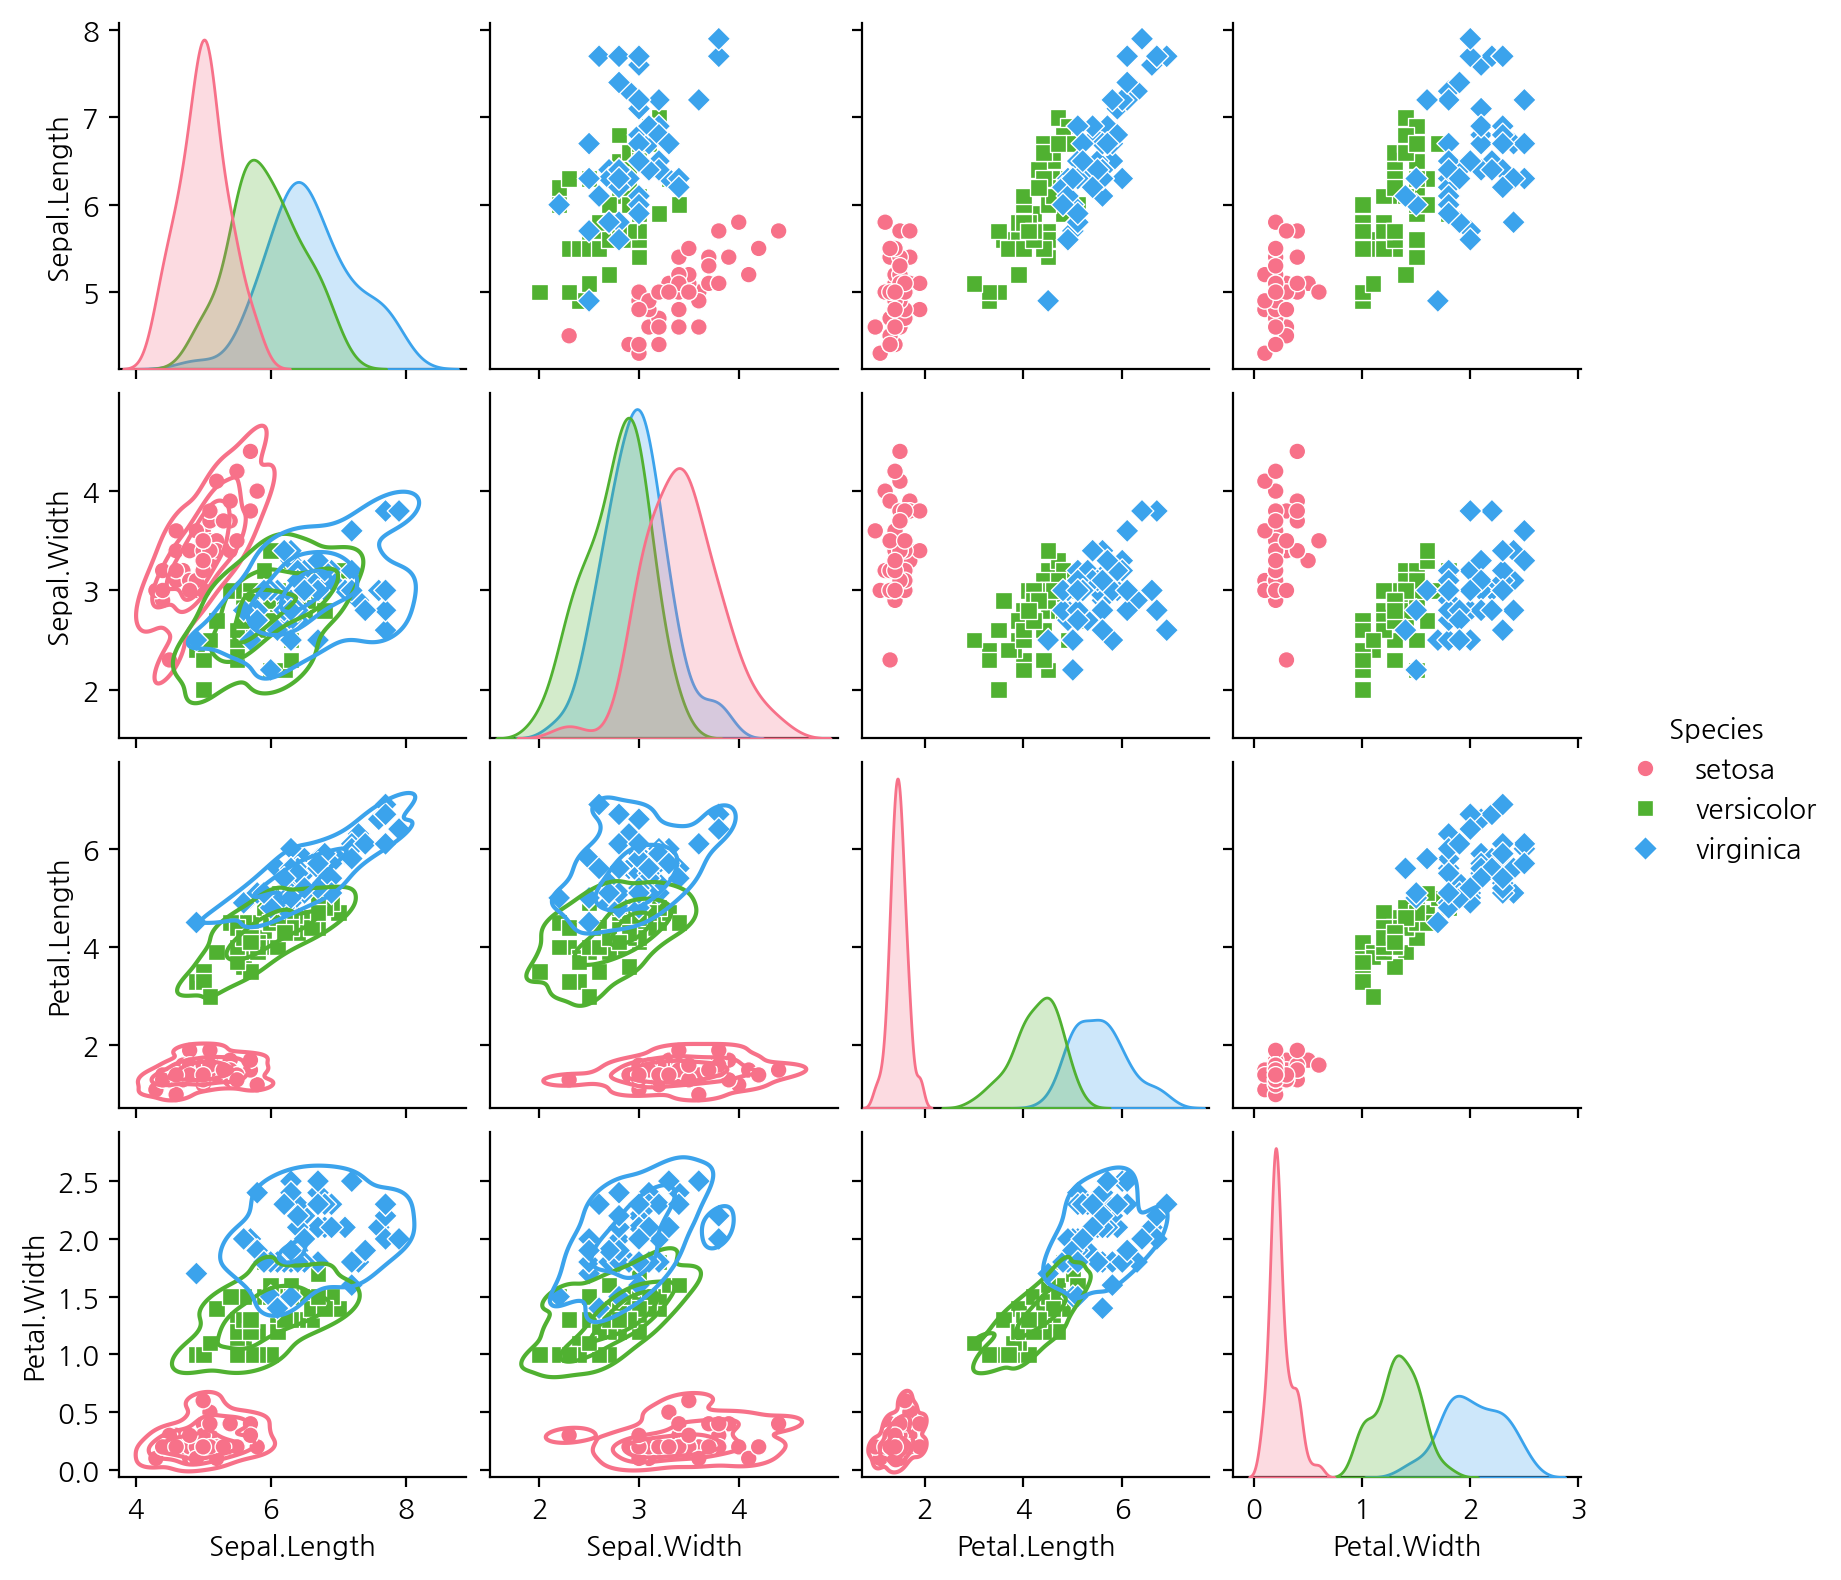

In [58]:
g = sns.pairplot(iris, hue="Species",
                 palette="husl", height=2.0,
                 markers=["o","s","D"]);
g.map_lower(sns.kdeplot, levels=4,
            color=".2");